In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("../datasets/processed/cleaned_injuries.csv")

## Abstract

This project presents a comparative data analysis of injury patterns across four major professional sports leagues in the United States: the NFL, NBA, NHL, and MLB.

The study aims to identify differences in injury distribution, severity, and anatomical impact between leagues, with a particular focus on head injuries due to their long-term neurological consequences.

To achieve this, multiple heterogeneous datasets were collected, cleaned, and standardized into a unified analytical dataset. Injury descriptions were categorized into broader anatomical groups to enable meaningful comparison across leagues.

Exploratory data analysis is conducted to examine injury distributions and trends, followed by statistical evaluation of key hypotheses related to injury frequency and severity.

The findings provide insight into how different sports environments influence injury risk, contributing to a better understanding of athlete safety and injury dynamics.

## Methods

### Data Collection

Data was collected from multiple publicly available sources covering injuries in the NFL, NBA, NHL, and MLB. Each dataset varies in structure, level of detail, and reporting format.

---

### Data Cleaning and Preprocessing

Due to the heterogeneity of the datasets, a comprehensive preprocessing pipeline was applied, including:

- Removal of duplicate entries
- Handling of missing values
- Standardization of column names
- Normalization of textual injury descriptions

Special attention was given to datasets containing unstructured data (e.g., NBA), where keyword-based extraction was used to derive injury types.

---

### Injury Categorization

To enable cross-league comparison, injury descriptions were mapped into broader anatomical categories:

- Head
- Upper Body
- Lower Body
- Other

Additional categories such as *Rest/Non-injury*, *Illness*, and *Unknown* were introduced to separate non-injury cases from true injury events.

This categorization was implemented using a rule-based keyword matching approach.

---

### Data Integration

After preprocessing, all datasets were aligned to a common schema and merged into a single unified dataset. This allowed consistent analysis across leagues.

---

### Exploratory Data Analysis (EDA)

EDA techniques were applied to explore:

- Overall injury distributions
- Injury patterns by league
- Frequency of head injuries
- Injury severity based on games missed

---

### Statistical Approach

The analysis is guided by predefined hypotheses. Visual and quantitative methods are used to assess differences between leagues and injury categories.

Where appropriate, statistical tests are applied to evaluate the significance of observed patterns.

## Research Hypotheses

This study is guided by the following hypotheses:

---

### H1: Injury Distribution Differences Across Leagues

There are statistically significant differences in the distribution of injury categories between sports leagues.

This hypothesis tests whether different sports environments lead to distinct injury profiles.

---

### H2: Contact Sports and Head Injury Risk

Contact-intensive sports (NFL and NHL) exhibit a higher proportion of head injuries compared to less contact-driven sports (NBA and MLB).

This hypothesis is based on the physical nature of gameplay and collision frequency.

---

### H3: Dominance of Lower Body Injuries

Lower body injuries represent the most common injury category across all leagues.

This reflects the biomechanical demands placed on athletes during performance.

---

### H4: Injury Severity Differences

The severity of injuries, measured by the number of games missed, differs significantly across injury categories.

In particular, head injuries are expected to result in longer recovery periods.

---

### H5: Variability in Injury Patterns

Injury patterns (distribution and frequency) show greater variability in high-contact sports compared to lower-contact sports.

This hypothesis explores whether increased physical intensity leads to more diverse injury outcomes.

### Hypothesis Testing Framework

Each hypothesis will be evaluated using a combination of exploratory data analysis and statistical testing.

Categorical comparisons will be assessed using distribution-based methods, while differences in injury severity will be analyzed using numerical metrics.

The results will be interpreted in the context of sport-specific dynamics and data limitations.

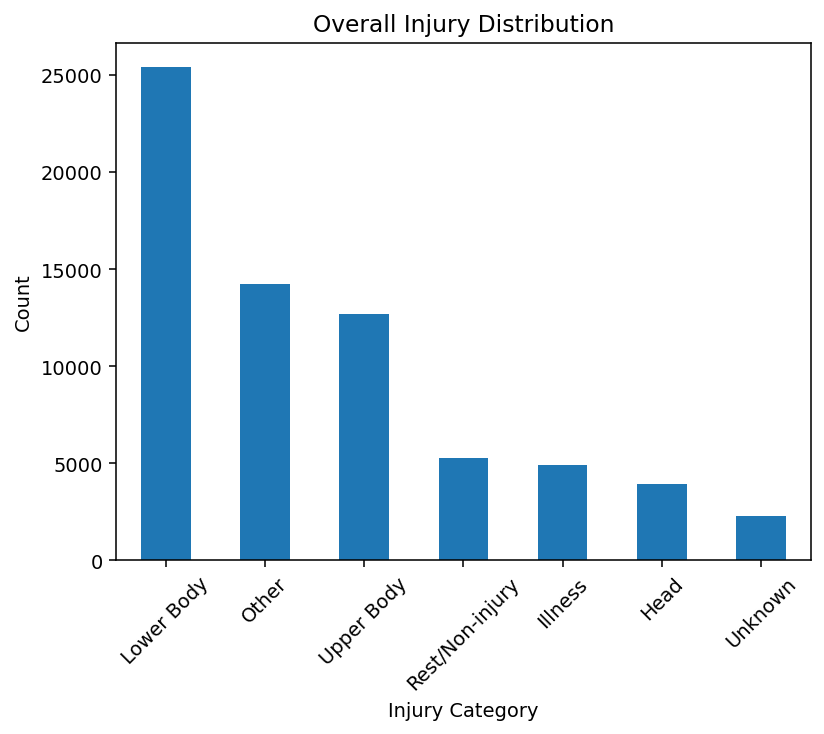

In [2]:
df["injury_category"].value_counts().plot(kind="bar")
plt.title("Overall Injury Distribution")
plt.xlabel("Injury Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Overall Injury Distribution

We begin by visualizing the distribution of injury categories across all leagues.

This helps identify which types of injuries are most common and provides a baseline for further comparison.

We expect lower body injuries to dominate due to the physical demands of sports.

The results show that lower body injuries are indeed the most frequent, followed by upper body and head injuries.

This aligns with the nature of high-intensity sports where legs are heavily involved.

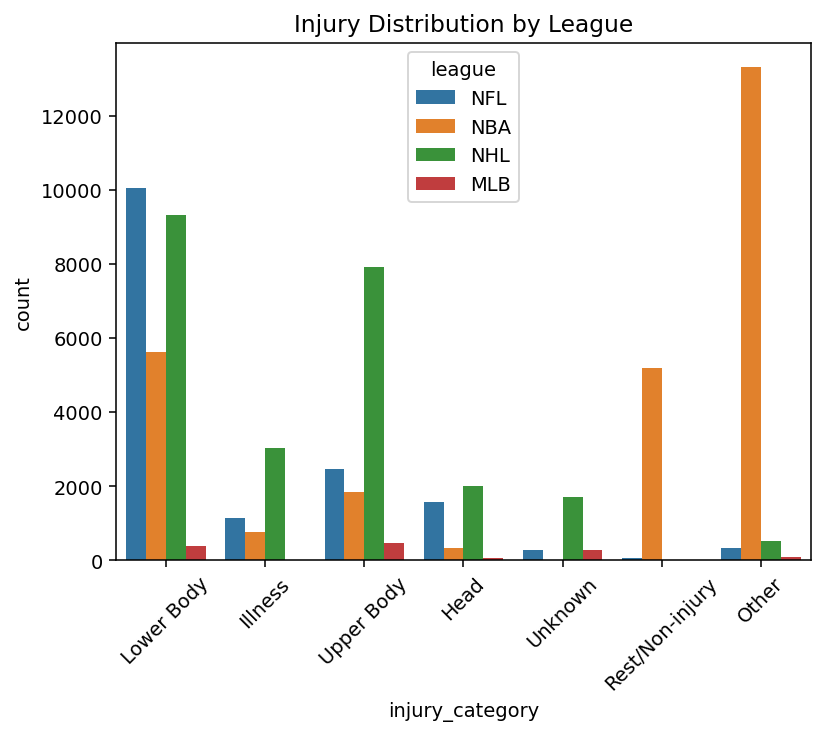

In [3]:
sns.countplot(data=df, x="injury_category", hue="league")
plt.title("Injury Distribution by League")
plt.xticks(rotation=45)
plt.show()

### Injury Distribution by League

We compare injury categories across different leagues to identify structural differences.

We expect contact-heavy sports such as NFL and NHL to show higher proportions of head injuries.

The visualization reveals that certain leagues exhibit distinct injury profiles, reflecting differences in gameplay and physical contact.

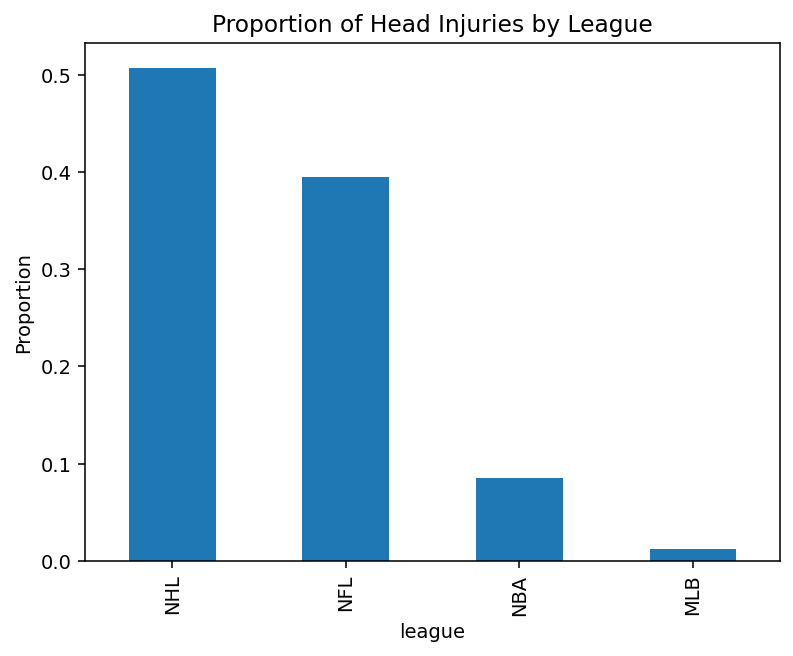

In [4]:
head_df = df[df["injury_category"] == "Head"]

head_distribution = head_df["league"].value_counts(normalize=True)

head_distribution.plot(kind="bar")
plt.title("Proportion of Head Injuries by League")
plt.ylabel("Proportion")
plt.show()

### Head Injury Distribution

Head injuries are analyzed separately due to their long-term neurological implications.

We examine their proportion across leagues to assess relative exposure to concussion-related risk.

We expect higher proportions in contact sports such as NFL and NHL.

The results indicate that these leagues indeed show elevated head injury proportions, supporting the hypothesis.

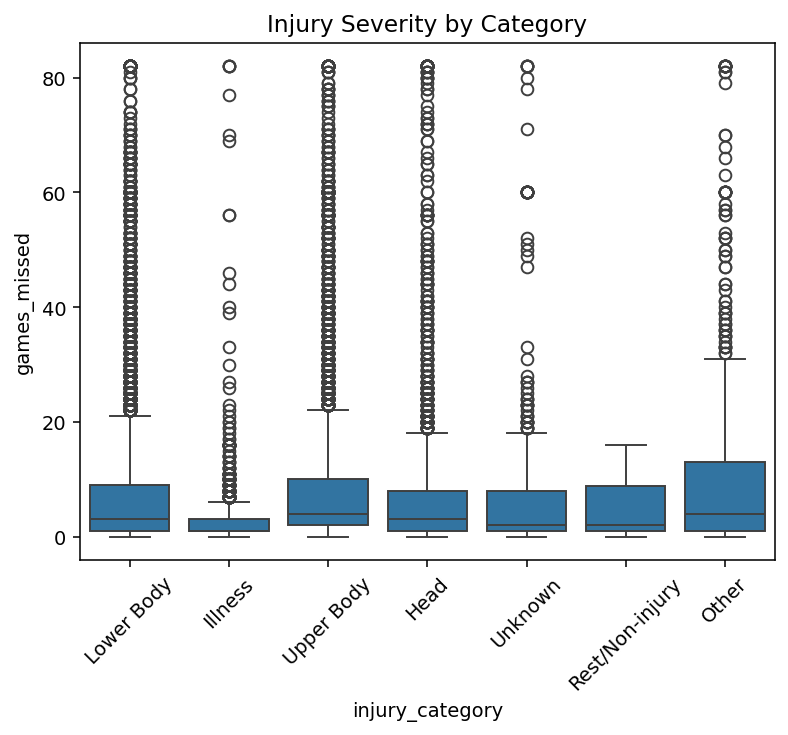

In [5]:
sns.boxplot(data=df, x="injury_category", y="games_missed")
plt.title("Injury Severity by Category")
plt.xticks(rotation=45)
plt.show()

### Injury Severity Analysis

We analyze injury severity using the number of games missed.

We expect head injuries to result in longer recovery periods due to their complexity.

The results show variability across categories, with some injury types leading to significantly longer absences.

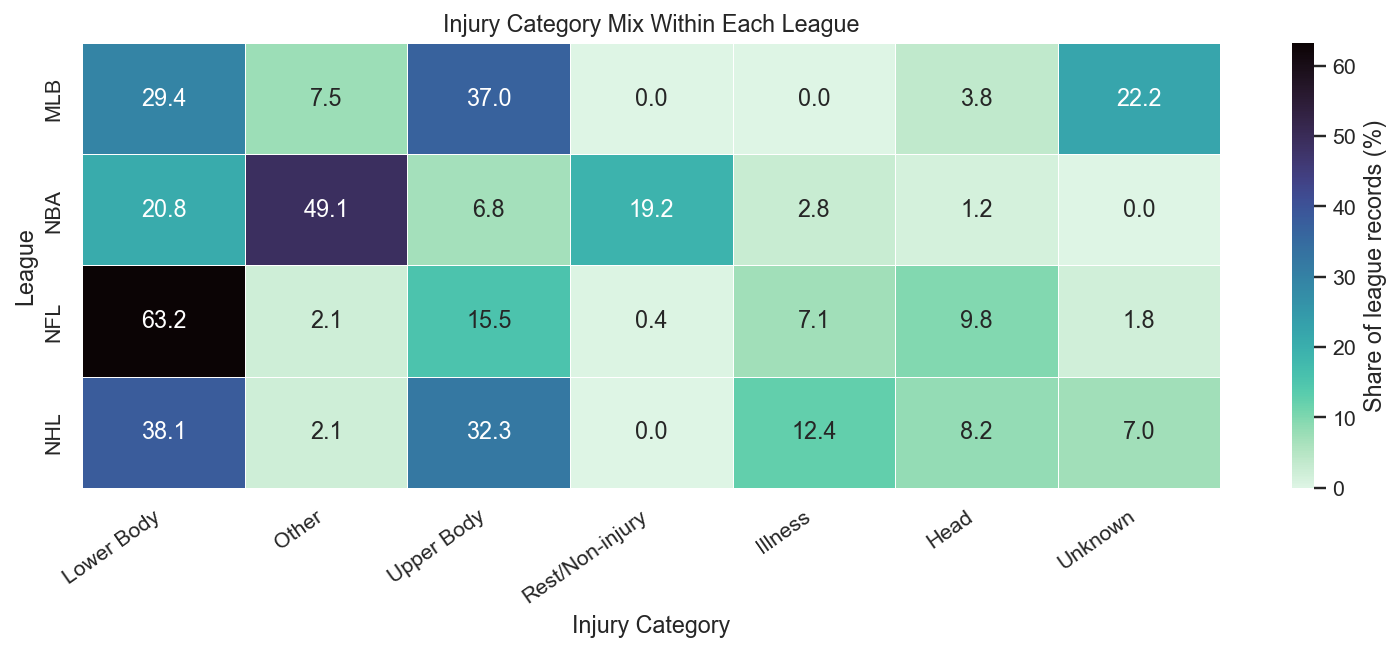

In [6]:
sns.set_theme(style="whitegrid", context="notebook")

category_order = df["injury_category"].value_counts().index
league_category_share = (
    pd.crosstab(df["league"], df["injury_category"], normalize="index")
    .reindex(columns=category_order)
    .mul(100)
)

plt.figure(figsize=(11, 4.8))
sns.heatmap(
    league_category_share,
    annot=True,
    fmt=".1f",
    cmap="mako_r",
    linewidths=0.5,
    cbar_kws={"label": "Share of league records (%)"}
)
plt.title("Injury Category Mix Within Each League")
plt.xlabel("Injury Category")
plt.ylabel("League")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


### League Injury Profile Heatmap

The earlier grouped count plot shows raw volume, but raw volume can be misleading because each league contributes a different number of records. A row-normalized heatmap is more suitable here: each row sums to 100%, so the comparison focuses on injury mix rather than dataset size.

This view is especially useful for testing whether leagues have distinct injury signatures. NFL injuries are dominated by lower-body records, NHL has a much more balanced lower-body and upper-body profile, MLB has a comparatively large upper-body share, and NBA contains a large `Other`/rest-management signal that should be interpreted as a data and reporting feature as much as a medical pattern. Head injuries remain a minority category everywhere, but they occupy a visibly larger share in the collision-heavy NFL and NHL rows than in NBA or MLB.


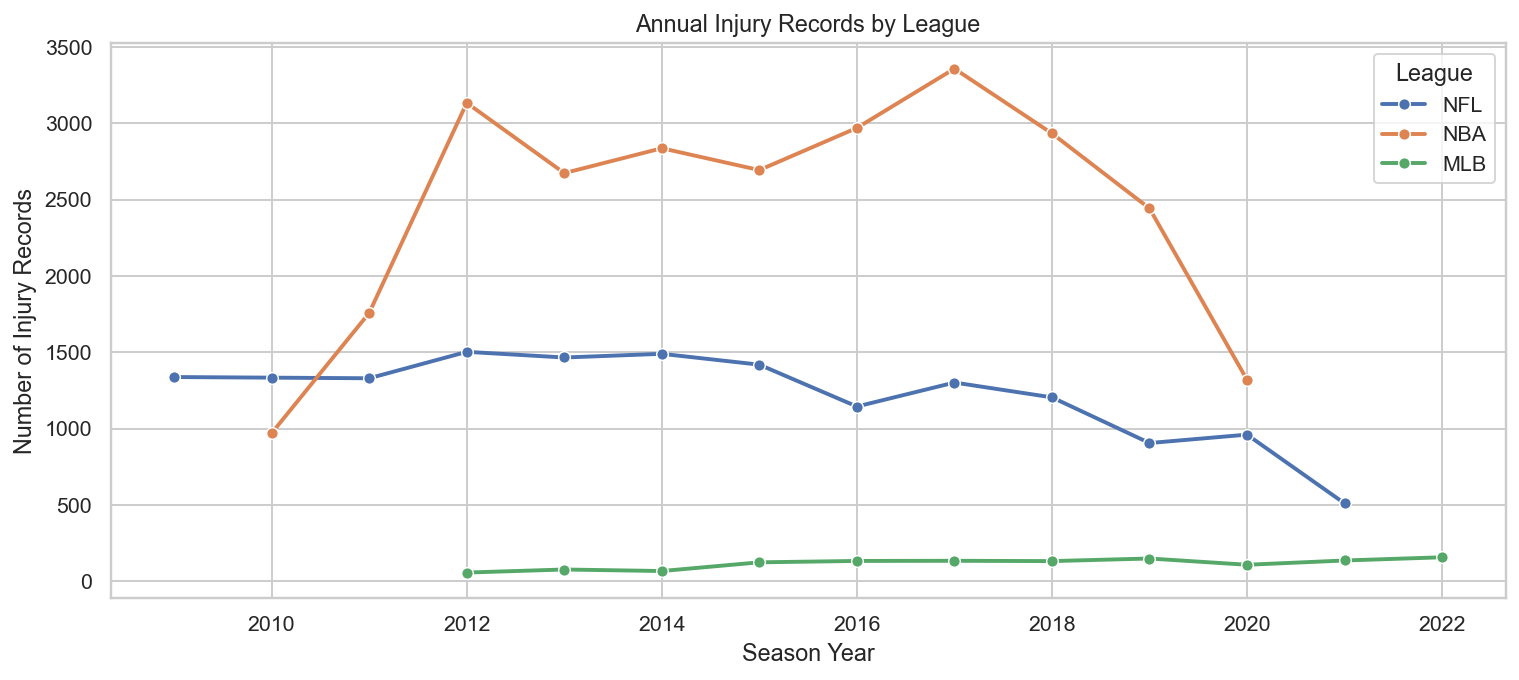

In [7]:
trend_df = df.copy()
trend_df["year"] = pd.to_numeric(trend_df["year"], errors="coerce")
trend_df = trend_df[trend_df["year"].between(1900, 2030)].copy()
trend_df["year"] = trend_df["year"].astype(int)

yearly_counts = (
    trend_df.groupby(["year", "league"])
    .size()
    .reset_index(name="injury_records")
)

plt.figure(figsize=(11, 5))
sns.lineplot(
    data=yearly_counts,
    x="year",
    y="injury_records",
    hue="league",
    marker="o",
    linewidth=2
)
plt.title("Annual Injury Records by League")
plt.xlabel("Season Year")
plt.ylabel("Number of Injury Records")
plt.legend(title="League")
plt.tight_layout()
plt.show()


### Injury Reporting Trends Over Time

A year-by-year line plot adds the temporal dimension that is missing from the first charts. Because the source datasets do not cover identical seasons and the NHL data in this cleaned file does not contain usable season years, this chart should be read as a within-league reporting trend rather than a perfect league-to-league incidence comparison.

The main analytical value is in slope and disruption: sudden jumps can indicate real injury environment changes, but they can also reflect changes in source coverage, reporting rules, scraping completeness, or season structure. For a final project, this is a good place to be transparent: temporal patterns are informative, but they are only as strong as the consistency of the underlying collection process.


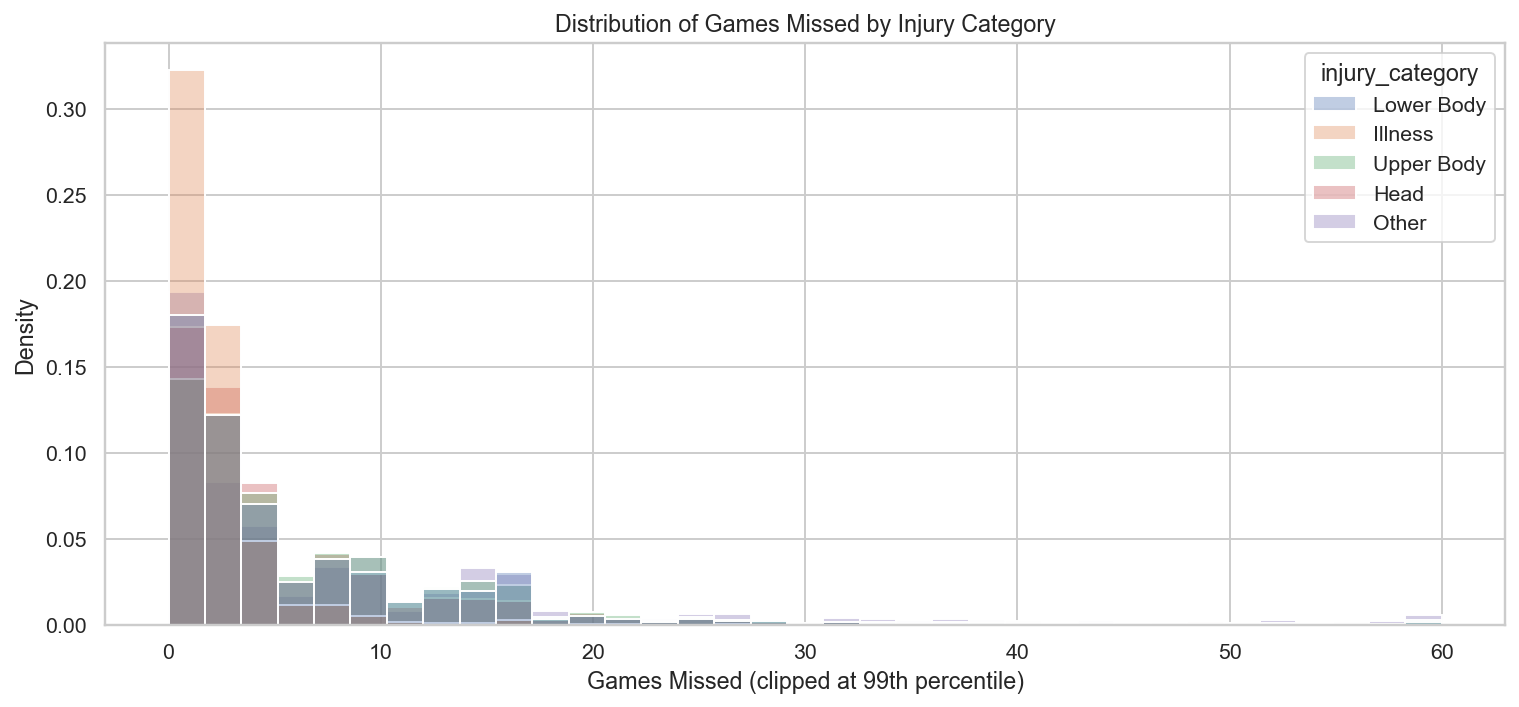

In [8]:
severity_df = df.copy()
severity_df["games_missed"] = pd.to_numeric(severity_df["games_missed"], errors="coerce")
severity_df = severity_df[
    severity_df["games_missed"].notna()
    & ~severity_df["injury_category"].isin(["Rest/Non-injury", "Unknown"])
].copy()
p99_games_missed = severity_df["games_missed"].quantile(0.99)
severity_plot_df = severity_df[severity_df["games_missed"] <= p99_games_missed]

plt.figure(figsize=(11, 5.2))
sns.histplot(
    data=severity_plot_df,
    x="games_missed",
    hue="injury_category",
    bins=35,
    multiple="layer",
    stat="density",
    common_norm=False,
    alpha=0.35
)
plt.title("Distribution of Games Missed by Injury Category")
plt.xlabel("Games Missed (clipped at 99th percentile)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


### Severity Distribution: Games Missed

`games_missed` is strongly right-skewed: many records involve short absences, while a small number represent long recovery periods. A standard boxplot reveals outliers, but a histogram makes the shape of the absence distribution easier to understand.

This chart clips the x-axis at the 99th percentile so that the common recovery range remains visible instead of being compressed by extreme cases. Filtering out `Rest/Non-injury` and `Unknown` also keeps the view focused on interpretable medical categories. The expected pattern is a steep concentration near zero to a few missed games, with head, upper-body, and lower-body injuries carrying longer tails. That tail is important: even if most injuries are short, roster impact and athlete welfare are often driven by the less frequent severe cases.


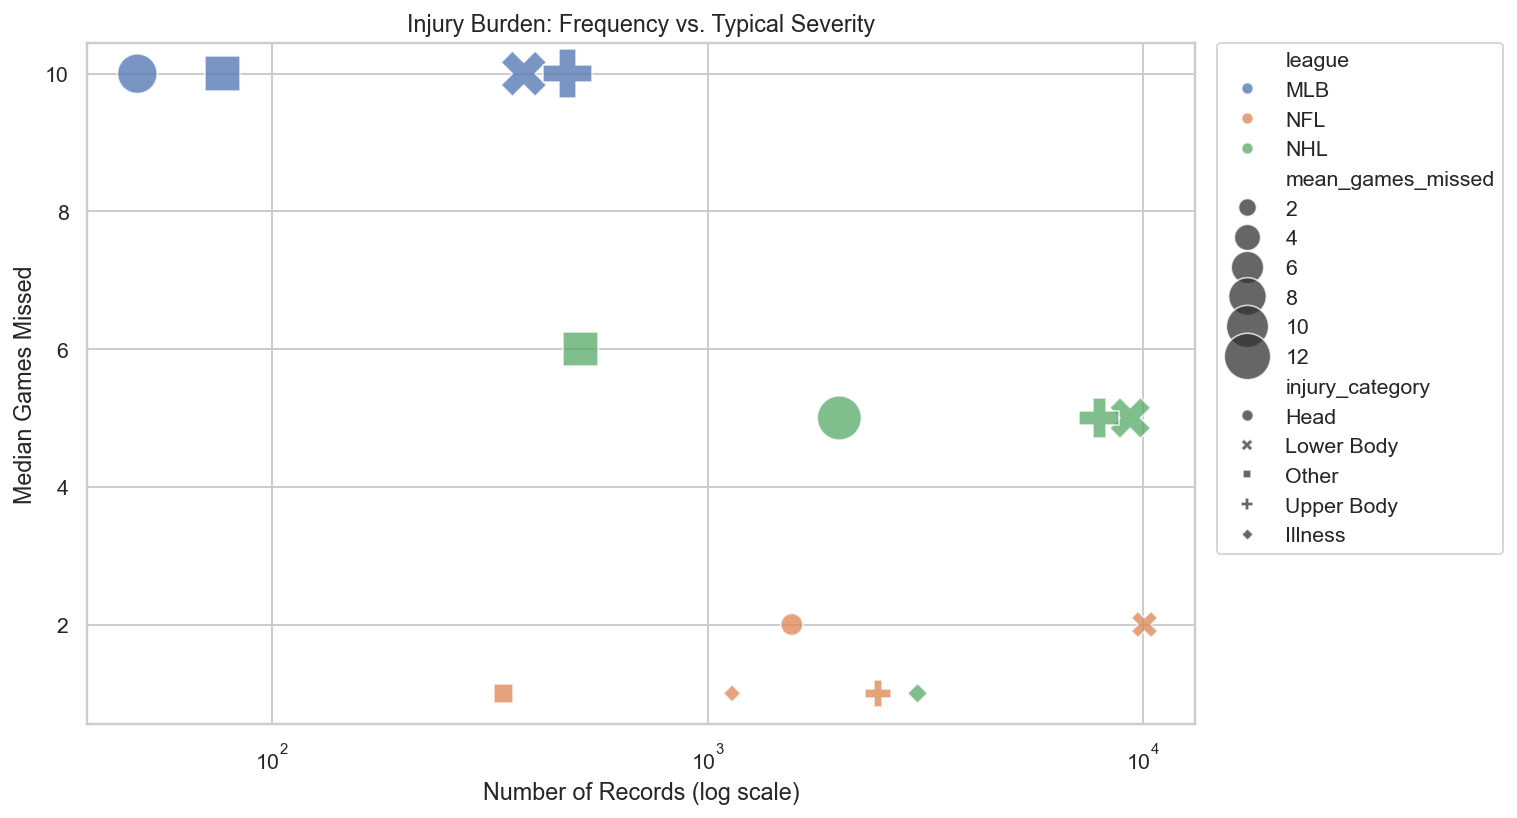

In [9]:
profile_df = severity_df.groupby(["league", "injury_category"]).agg(
    records=("games_missed", "size"),
    median_games_missed=("games_missed", "median"),
    mean_games_missed=("games_missed", "mean")
).reset_index()
profile_df = profile_df[profile_df["records"] >= 30].copy()

plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=profile_df,
    x="records",
    y="median_games_missed",
    hue="league",
    style="injury_category",
    size="mean_games_missed",
    sizes=(80, 650),
    alpha=0.75
)
plt.xscale("log")
plt.title("Injury Burden: Frequency vs. Typical Severity")
plt.xlabel("Number of Records (log scale)")
plt.ylabel("Median Games Missed")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()


### Frequency vs. Severity Bubble Map

A useful EDA question is not only "which injuries are common?" or "which injuries are severe?" but which league-category combinations combine both. The bubble plot answers that by placing record count on the x-axis and median games missed on the y-axis, with bubble size showing mean games missed.

This is a more decision-oriented view: combinations in the upper-right are both frequent and severe, making them strong candidates for prevention, workload, and medical-staff attention. Combinations with high median severity but low count may represent rare but costly events. This plot also helps separate noise from signal; categories with very small sample sizes are excluded so the visual is less likely to overreact to one unusual absence.


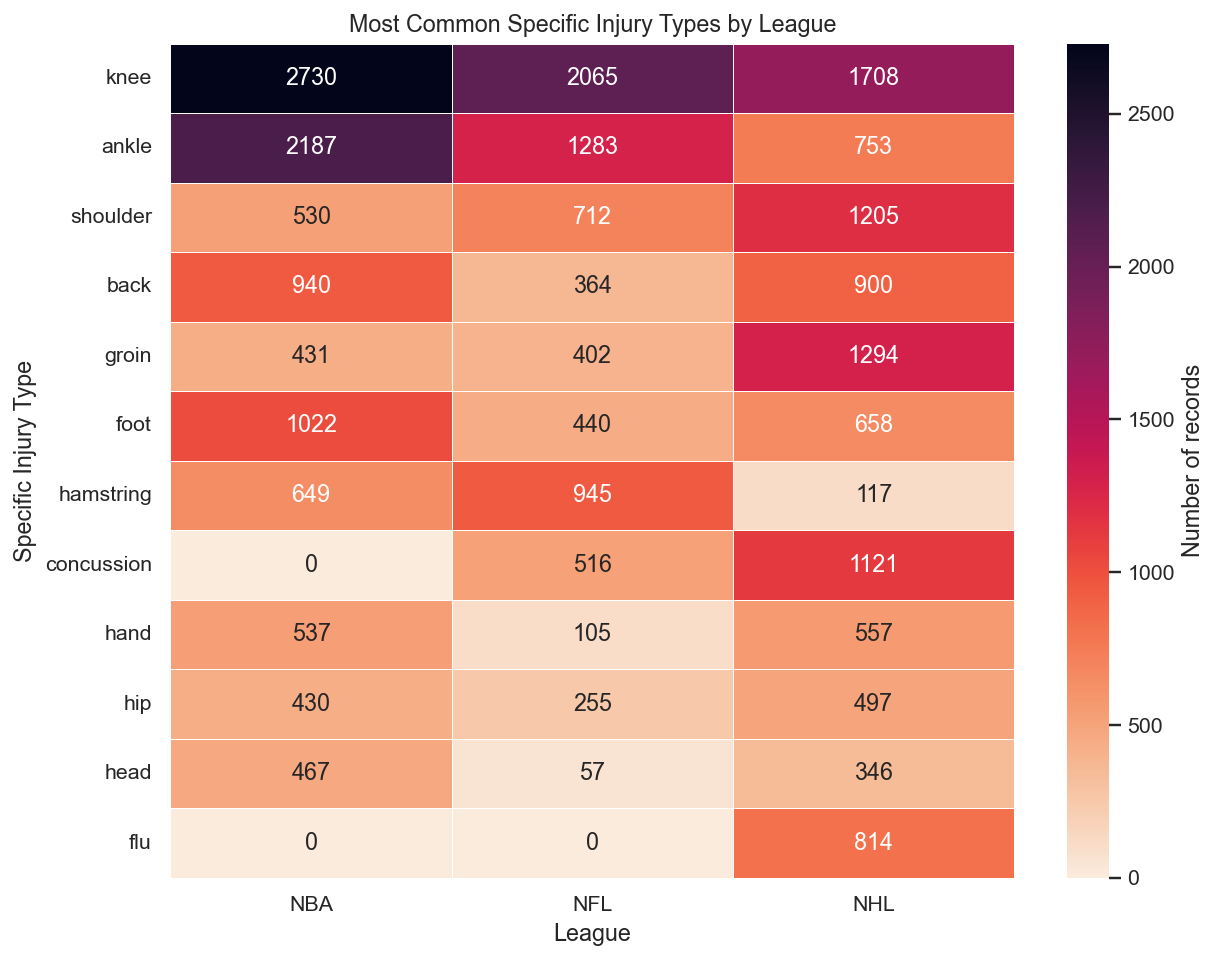

In [10]:
generic_injury_labels = {
    "other", "unknown", "undisclosed", "upper body", "lower body",
    "illness", "rest", "not injury related"
}

specific_df = df.copy()
specific_df["injury_type"] = specific_df["injury_type"].astype(str).str.lower().str.strip()
specific_df = specific_df[~specific_df["injury_type"].isin(generic_injury_labels)]
top_specific_injuries = specific_df["injury_type"].value_counts().head(12).index

specific_heatmap = pd.crosstab(
    specific_df[specific_df["injury_type"].isin(top_specific_injuries)]["injury_type"],
    specific_df[specific_df["injury_type"].isin(top_specific_injuries)]["league"]
).reindex(top_specific_injuries)

plt.figure(figsize=(9, 7))
sns.heatmap(
    specific_heatmap,
    annot=True,
    fmt="d",
    cmap="rocket_r",
    linewidths=0.5,
    cbar_kws={"label": "Number of records"}
)
plt.title("Most Common Specific Injury Types by League")
plt.xlabel("League")
plt.ylabel("Specific Injury Type")
plt.tight_layout()
plt.show()


### Specific Injury Types by League

The broad categories are excellent for hypothesis testing, but they hide the vocabulary of actual injuries. This heatmap returns to the cleaned `injury_type` field and focuses on the most frequent specific labels after removing generic placeholders such as `other`, `unknown`, and `undisclosed`.

The result is a practical scouting-style view of what drives each league profile. Knee, ankle, shoulder, back, groin, foot, hamstring, concussion, hand, hip, and head labels are more actionable than broad anatomical buckets. If one league dominates a specific row, that suggests a sport-specific mechanism or reporting convention worth discussing in the final interpretation. If a row is spread across multiple leagues, the injury is probably part of a shared professional-sport workload pattern.
